<a href="https://colab.research.google.com/github/Dr-Isam-ALJAWARNEH/fds-project-geodevelopers/blob/main/Minimum_Spanning_Tree_for_Optimizing_Pollution_Monitoring_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Minimum Spanning Tree (MST) for Optimizing Pollution Monitoring Networks**

## **Importing the Required Libraries**

In [2]:
%pip install pygeohash

In [3]:
import pandas as pd
import geopandas as gpd
import pygeohash as gh
import numpy as np

In [4]:
from datascience import *
%matplotlib inline
#path_data = '../../../assets/data/'
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

In [5]:
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from geopy.distance import great_circle
from sklearn.preprocessing import StandardScaler

In [6]:
import time
from scipy.spatial import distance_matrix
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.spatial.distance import pdist, squareform

## **Configuring Variables & Importing Files**

In [7]:
Geohash_percision = 6

In [8]:
#Create new dataframe table, and import all available Chicago files in the repositry to it.
Chicago_df_original = Table().to_df()

for i in range(1,20):
  file_link = 'https://raw.githubusercontent.com/IsamAljawarneh/datasets/refs/heads/master/data/Chicago/AQ_data/chicago_eclipse_data_part_'+str(i)+'.csv'
  Chicago_df_original = pd.concat([Chicago_df_original, pd.read_csv(file_link,index_col=False)], ignore_index=True)

Chicago_df_original

,City,DeviceId,LocationName,Latitude,Longitude,ReadingDateTimeUTC,PM25,CalibratedPM25,CalibratedO3,CalibratedNO2,CO,Temperature,Humidity,BatteryLevel,PercentBattery,CellSignal
0,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:03:00,5.561094,NaN,NaN,NaN,0.123580,27.383499,55.128479,4.237187,93.964844,-76.0
1,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:08:10,6.633914,NaN,NaN,NaN,0.132103,27.079086,55.059814,4.236094,93.964844,-81.0
2,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:13:20,4.068707,NaN,NaN,NaN,0.131126,27.079086,55.035400,4.236406,93.964844,-80.0
3,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:18:30,6.351702,NaN,NaN,NaN,0.138784,26.945572,54.632568,4.236094,93.863281,-82.0
4,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:23:40,9.574065,NaN,NaN,NaN,0.413070,26.828079,53.907776,4.235938,93.863281,-81.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2461084,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:29:48,4.479115,10.72,34.66,12.51,0.413648,22.817307,73.245239,4.176250,89.785156,-62.0
2461085,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:34:58,6.322502,14.89,34.71,6.35,0.656208,22.713165,73.222351,4.186875,89.785156,-61.0
2461086,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:40:08,9.796841,13.51,36.71,2.62,0.336273,22.659760,73.472595,4.186250,89.683594,-60.0
2461087,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:45:17,5.173977,11.20,34.33,3.53,0.372924,22.526245,73.468018,4.186250,89.683594,-61.0


## **Exploring & Analyzing the Data**

## **Cleaning & Organizing the Data**

In [9]:
Chicago_df_all = Chicago_df_original
Chicago_df_all['ReadingDate'] = pd.to_datetime(Chicago_df_all['ReadingDateTimeUTC'])
Chicago_df_all

,City,DeviceId,LocationName,Latitude,Longitude,ReadingDateTimeUTC,PM25,CalibratedPM25,CalibratedO3,CalibratedNO2,CO,Temperature,Humidity,BatteryLevel,PercentBattery,CellSignal,ReadingDate
0,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:03:00,5.561094,NaN,NaN,NaN,0.123580,27.383499,55.128479,4.237187,93.964844,-76.0,2021-06-20 00:03:00
1,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:08:10,6.633914,NaN,NaN,NaN,0.132103,27.079086,55.059814,4.236094,93.964844,-81.0,2021-06-20 00:08:10
2,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:13:20,4.068707,NaN,NaN,NaN,0.131126,27.079086,55.035400,4.236406,93.964844,-80.0,2021-06-20 00:13:20
3,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:18:30,6.351702,NaN,NaN,NaN,0.138784,26.945572,54.632568,4.236094,93.863281,-82.0,2021-06-20 00:18:30
4,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:23:40,9.574065,NaN,NaN,NaN,0.413070,26.828079,53.907776,4.235938,93.863281,-81.0,2021-06-20 00:23:40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2461084,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:29:48,4.479115,10.72,34.66,12.51,0.413648,22.817307,73.245239,4.176250,89.785156,-62.0,2021-10-03 23:29:48
2461085,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:34:58,6.322502,14.89,34.71,6.35,0.656208,22.713165,73.222351,4.186875,89.785156,-61.0,2021-10-03 23:34:58
2461086,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:40:08,9.796841,13.51,36.71,2.62,0.336273,22.659760,73.472595,4.186250,89.683594,-60.0,2021-10-03 23:40:08
2461087,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:45:17,5.173977,11.20,34.33,3.53,0.372924,22.526245,73.468018,4.186250,89.683594,-61.0,2021-10-03 23:45:17


In [10]:
Chicago_ds_all = Table().from_df(Chicago_df_all)
Chicago_ds_all

City,DeviceId,LocationName,Latitude,Longitude,ReadingDateTimeUTC,PM25,CalibratedPM25,CalibratedO3,CalibratedNO2,CO,Temperature,Humidity,BatteryLevel,PercentBattery,CellSignal,ReadingDate
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:03:00,5.56109,nan,nan,nan,0.12358,27.3835,55.1285,4.23719,93.9648,-76,2021-06-20 00:03:00
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:08:10,6.63391,nan,nan,nan,0.132103,27.0791,55.0598,4.23609,93.9648,-81,2021-06-20 00:08:10
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:13:20,4.06871,nan,nan,nan,0.131126,27.0791,55.0354,4.23641,93.9648,-80,2021-06-20 00:13:20
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:18:30,6.3517,nan,nan,nan,0.138784,26.9456,54.6326,4.23609,93.8633,-82,2021-06-20 00:18:30
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:23:40,9.57407,nan,nan,nan,0.41307,26.8281,53.9078,4.23594,93.8633,-81,2021-06-20 00:23:40
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:28:50,6.02794,nan,nan,nan,0.157761,26.7667,58.0338,4.23609,93.8633,-82,2021-06-20 00:28:50
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:34:00,3.61224,nan,nan,nan,0.115831,26.3367,56.1356,4.23625,93.8633,-81,2021-06-20 00:34:00
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:39:10,3.75591,nan,nan,nan,0.122269,26.2032,55.838,4.22625,93.8633,-81,2021-06-20 00:39:10
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:44:20,6.00689,nan,nan,nan,0.184926,26.1712,55.6427,4.23547,93.8633,-80,2021-06-20 00:44:20
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:49:30,8.50949,nan,nan,nan,0.11234,26.2032,55.4581,4.23609,93.8633,-80,2021-06-20 00:49:30


Text(0.5, 1.0, 'Daily Pollution Levels')

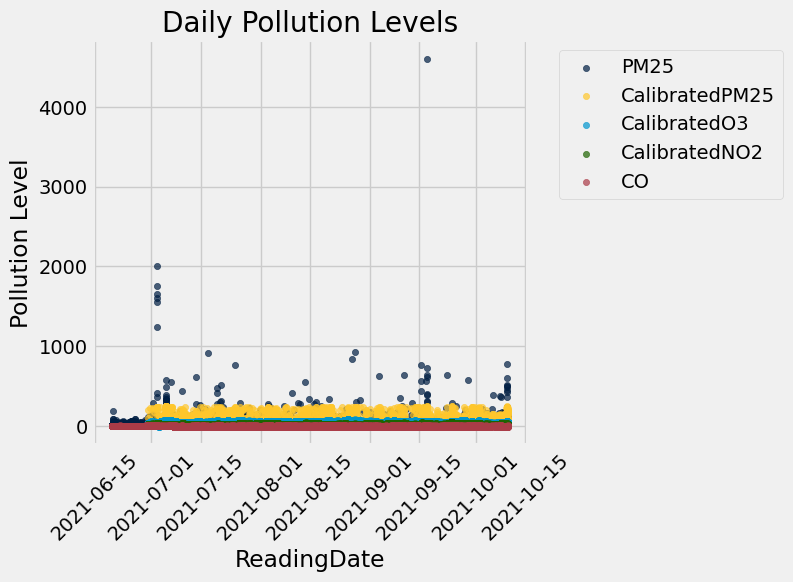

In [11]:
Chicago_ds_all.select("ReadingDate", "PM25", "CalibratedPM25", "CalibratedO3", "CalibratedNO2", "CO").scatter('ReadingDate')
plt.xticks(rotation=45)
plt.ylabel('Pollution Level')
plt.title('Pollution Levels vs ReadingDate')

Text(0.5, 1.0, 'Calibrated Pollution Levels vs ReadingDate')

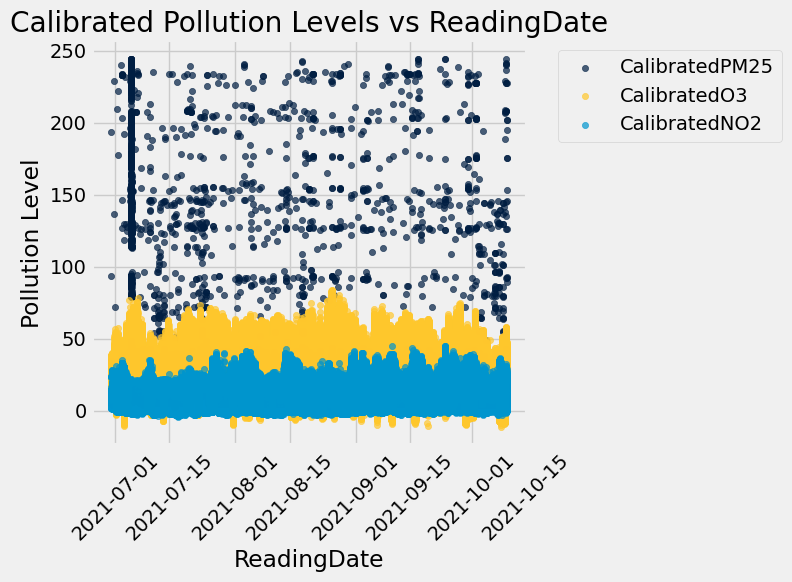

In [35]:
Chicago_ds_all.select("ReadingDate", "CalibratedPM25", "CalibratedO3", "CalibratedNO2").scatter('ReadingDate')
plt.xticks(rotation=45)
plt.ylabel('Pollution Level')
plt.title('Calibrated Pollution Levels vs ReadingDate')

In [19]:
def check_missing_values(ds_table):
  for label in ds_table.labels:
      column = ds_table.column(label)

      if np.issubdtype(type(column[0]), np.number):  # check numeric columns
          missing = np.count_nonzero(np.isnan(column))
      else:
          missing = np.count_nonzero(column == '')

      print(f"Missing values in '{label}': {missing}")
  print("num rows: ", ds_table.num_rows)

In [20]:
check_missing_values(Chicago_ds_all)

Missing values in 'City': 0
Missing values in 'DeviceId': 0
Missing values in 'LocationName': 0
Missing values in 'Latitude': 0
Missing values in 'Longitude': 0
Missing values in 'ReadingDateTimeUTC': 0
Missing values in 'PM25': 0
Missing values in 'CalibratedPM25': 34277
Missing values in 'CalibratedO3': 34277
Missing values in 'CalibratedNO2': 34277
Missing values in 'CO': 127
Missing values in 'Temperature': 0
Missing values in 'Humidity': 0
Missing values in 'BatteryLevel': 0
Missing values in 'PercentBattery': 0
Missing values in 'CellSignal': 0
Missing values in 'ReadingDate': 0
num rows:  2461089


In [21]:
Chicago_ds_cleaned = Chicago_ds_all.where(~np.isnan(Chicago_ds_all.column("CalibratedPM25")))
check_missing_values(Chicago_ds_cleaned)

Missing values in 'City': 0
Missing values in 'DeviceId': 0
Missing values in 'LocationName': 0
Missing values in 'Latitude': 0
Missing values in 'Longitude': 0
Missing values in 'ReadingDateTimeUTC': 0
Missing values in 'PM25': 0
Missing values in 'CalibratedPM25': 0
Missing values in 'CalibratedO3': 0
Missing values in 'CalibratedNO2': 0
Missing values in 'CO': 127
Missing values in 'Temperature': 0
Missing values in 'Humidity': 0
Missing values in 'BatteryLevel': 0
Missing values in 'PercentBattery': 0
Missing values in 'CellSignal': 0
Missing values in 'ReadingDate': 0
num rows:  2426812


In [22]:
Chicago_df_cleaned = Chicago_ds_cleaned.to_df()

In [23]:
def plot_pollution_vs(df_table, AnalyzingColumn):
  fig, axes = plt.subplots(1, 3, figsize=(18,5))
  df_table.plot.scatter(x = AnalyzingColumn, y = "CalibratedPM25", ax=axes[0], color="#001E42", title="CalibratedPM25 vs " + AnalyzingColumn)
  df_table.plot.scatter(x = AnalyzingColumn, y = "CalibratedO3", ax=axes[1], color="#FEC72C", title="CalibratedO3 vs " + AnalyzingColumn)
  df_table.plot.scatter(x = AnalyzingColumn, y = "CalibratedNO2", ax=axes[2], color="#0095CD", title="CalibratedNO2 vs " + AnalyzingColumn)

  for ax in axes:
    for label in ax.get_xticklabels():
      label.set_rotation(45)

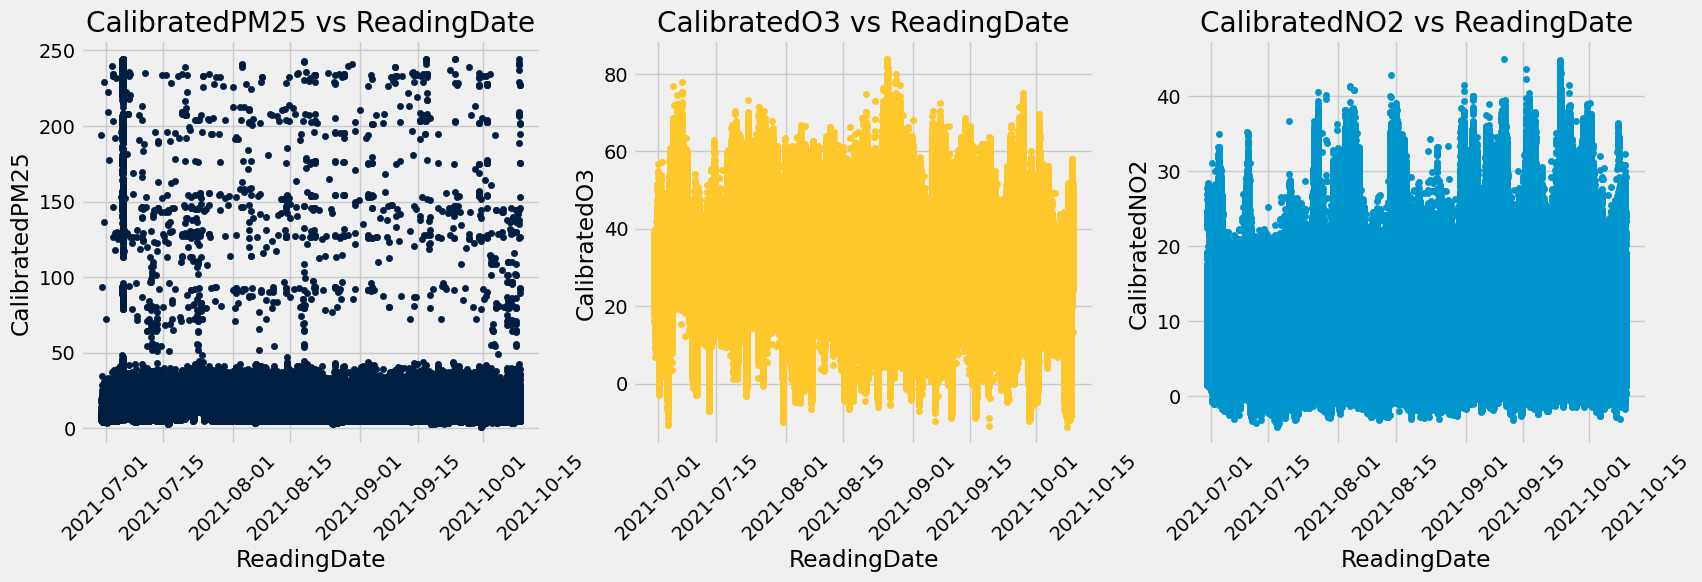

In [24]:
plot_pollution_vs(Chicago_df_cleaned, "ReadingDate")

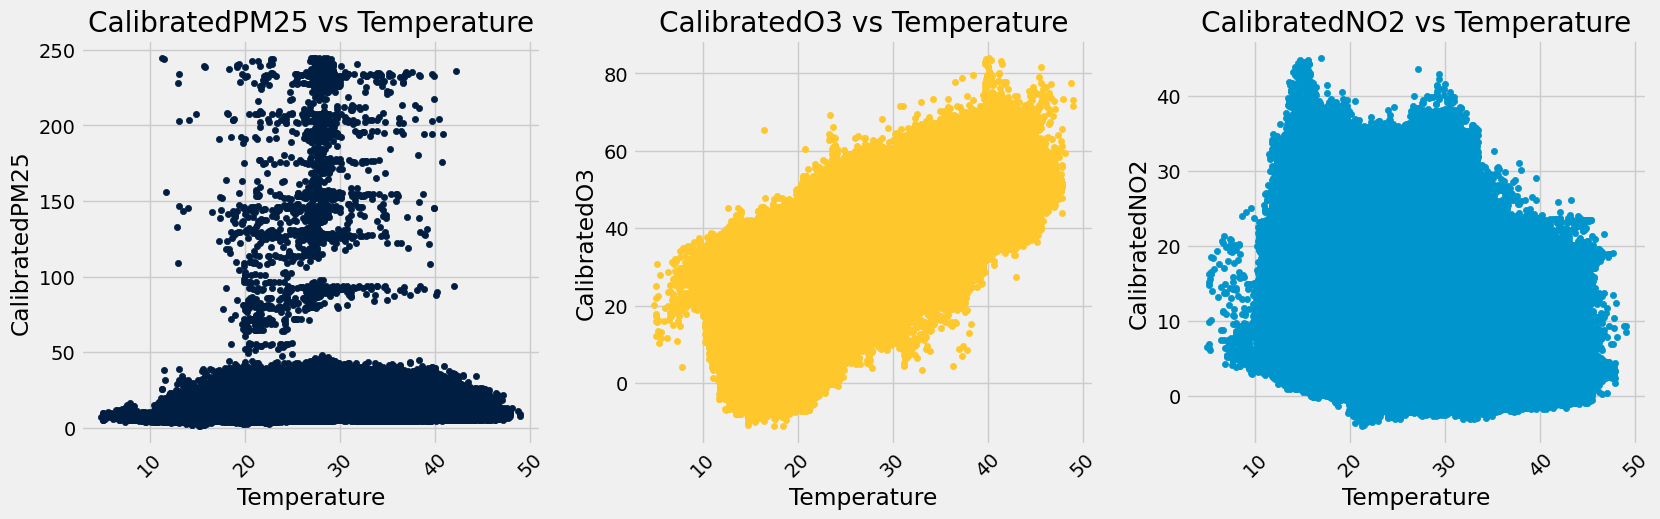

In [26]:
plot_pollution_vs(Chicago_df_cleaned, "Temperature")

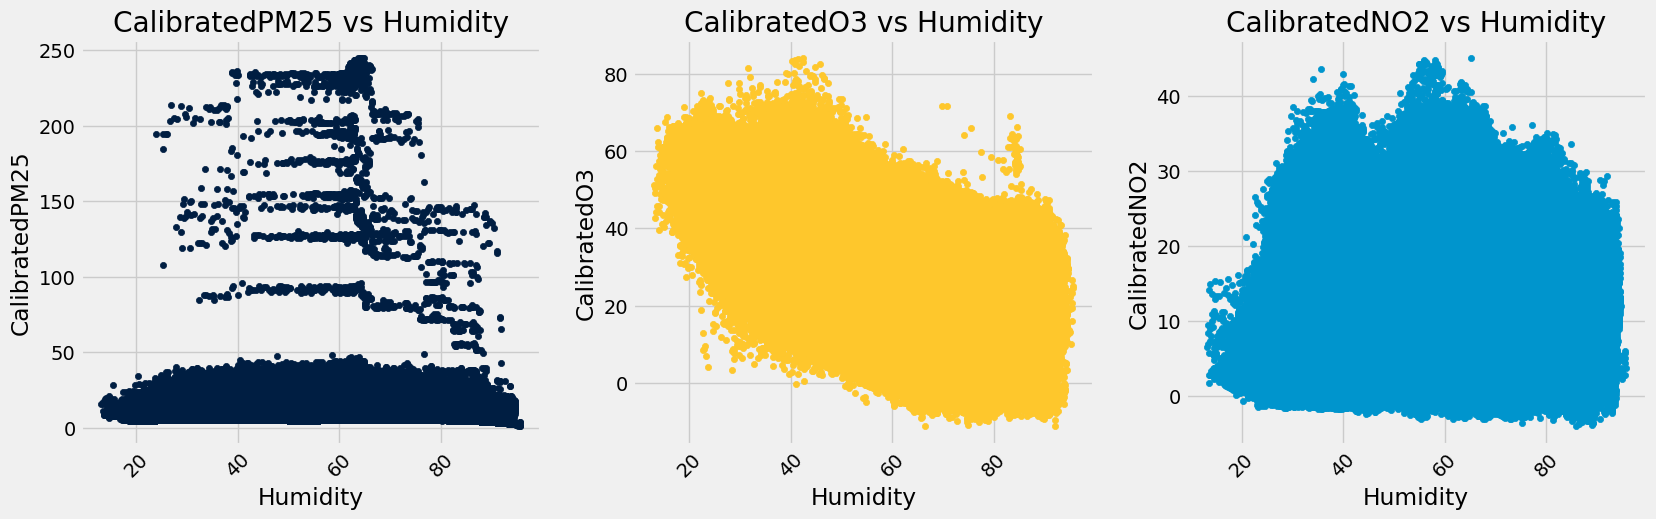

In [27]:
plot_pollution_vs(Chicago_df_cleaned, "Humidity")

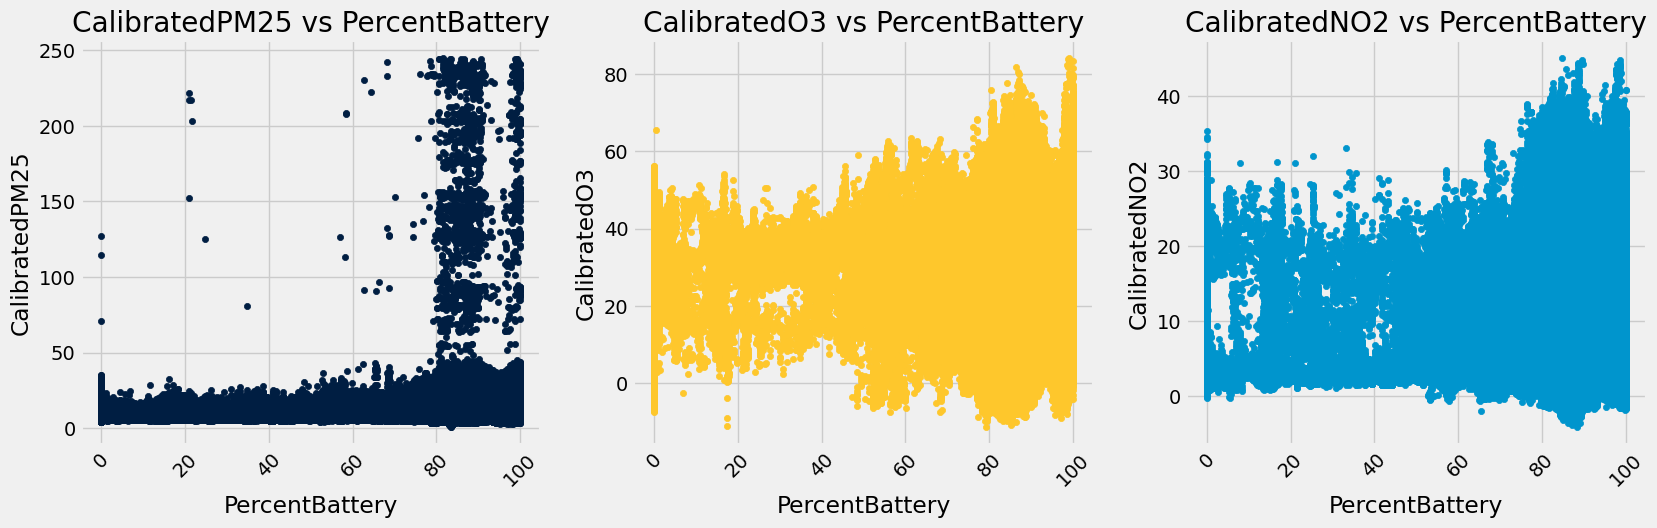

In [28]:
plot_pollution_vs(Chicago_df_cleaned, "PercentBattery")

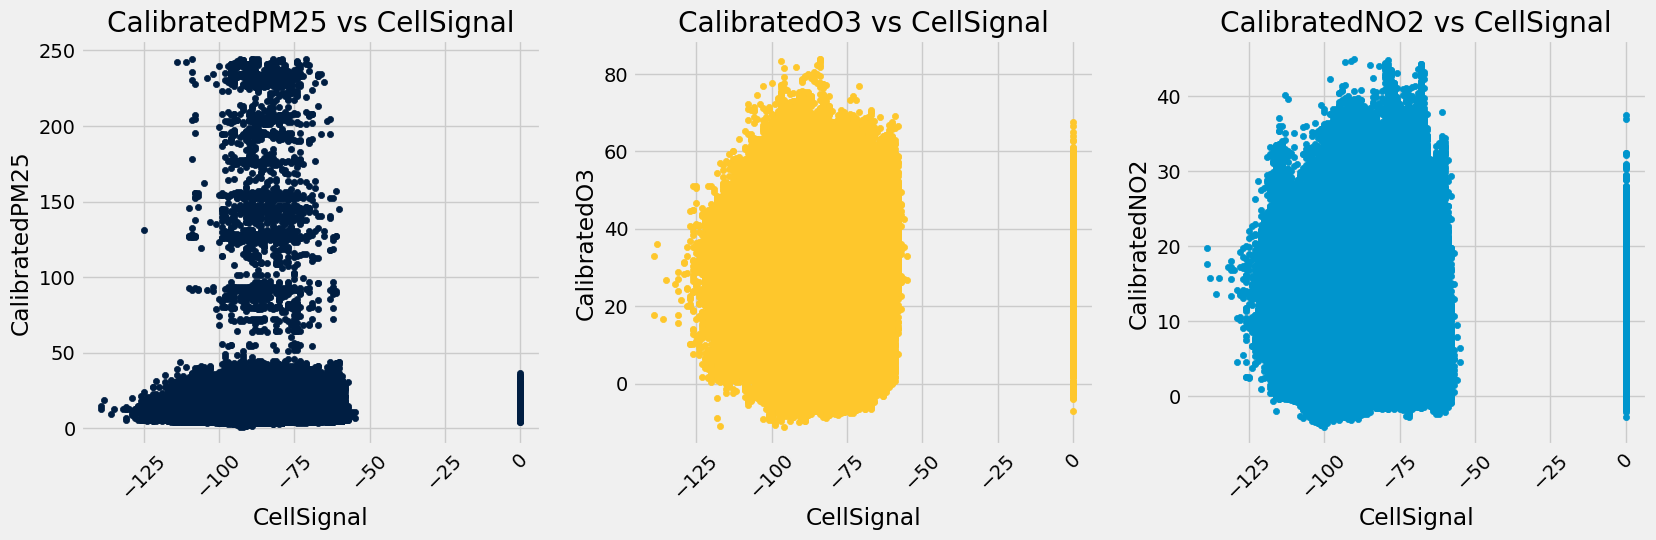

In [29]:
plot_pollution_vs(Chicago_df_cleaned, "CellSignal")

In [40]:
Chicago_df = Chicago_df_cleaned[["City",	"DeviceId",	"LocationName",	"Latitude",	"Longitude",	"ReadingDate", "CalibratedPM25",	"CalibratedO3",	"CalibratedNO2"]]
Chicago_df

,City,DeviceId,LocationName,Latitude,Longitude,ReadingDate,CalibratedPM25,CalibratedO3,CalibratedNO2
0,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-30 00:01:33,7.01,25.86,2.83
1,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-30 00:06:43,7.35,25.62,3.29
2,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-30 00:11:53,9.26,26.26,3.51
3,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-30 00:17:03,8.46,25.32,7.05
4,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-30 00:22:13,9.91,24.79,6.69
...,...,...,...,...,...,...,...,...,...
2426807,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:29:48,10.72,34.66,12.51
2426808,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:34:58,14.89,34.71,6.35
2426809,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:40:08,13.51,36.71,2.62
2426810,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:45:17,11.20,34.33,3.53


In [41]:
#Add Geohash grouping based on the latitude and longtiude columns
Chicago_df["GeoHash Code"] = Chicago_df.apply(lambda x: gh.encode(x.Latitude, x.Longitude, precision= Geohash_percision), axis=1)
Chicago_df

<ipython-input-41-2aceb0ec0caa>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Chicago_df["GeoHash Code"] = Chicago_df.apply(lambda x: gh.encode(x.Latitude, x.Longitude, precision= Geohash_percision), axis=1)


,City,DeviceId,LocationName,Latitude,Longitude,ReadingDate,CalibratedPM25,CalibratedO3,CalibratedNO2,GeoHash Code
0,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-30 00:01:33,7.01,25.86,2.83,dp3ty0
1,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-30 00:06:43,7.35,25.62,3.29,dp3ty0
2,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-30 00:11:53,9.26,26.26,3.51,dp3ty0
3,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-30 00:17:03,8.46,25.32,7.05,dp3ty0
4,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-30 00:22:13,9.91,24.79,6.69,dp3ty0
...,...,...,...,...,...,...,...,...,...,...
2426807,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:29:48,10.72,34.66,12.51,dp3wu7
2426808,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:34:58,14.89,34.71,6.35,dp3wu7
2426809,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:40:08,13.51,36.71,2.62,dp3wu7
2426810,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:45:17,11.20,34.33,3.53,dp3wu7


In [42]:
# Min-Max Normalization
pollution_columns = ['CalibratedPM25', 'CalibratedO3', 'CalibratedNO2']
for col in pollution_columns:
   Chicago_df[f'Normalized{col}'] = (Chicago_df[col] - Chicago_df[col].min()) / (Chicago_df[col].max() - Chicago_df[col].min())
# Combine normalized values into a pollution index
Chicago_df['TotalNormalizedPollution'] = Chicago_df[[f'Normalized{col}' for col in pollution_columns]].sum(axis=1)
Chicago_df

<ipython-input-42-16a28778290c>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Chicago_df[f'Normalized{col}'] = (Chicago_df[col] - Chicago_df[col].min()) / (Chicago_df[col].max() - Chicago_df[col].min())
<ipython-input-42-16a28778290c>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Chicago_df[f'Normalized{col}'] = (Chicago_df[col] - Chicago_df[col].min()) / (Chicago_df[col].max() - Chicago_df[col].min())
<ipython-input-42-16a28778290c>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of

,City,DeviceId,LocationName,Latitude,Longitude,ReadingDate,CalibratedPM25,CalibratedO3,CalibratedNO2,GeoHash Code,NormalizedCalibratedPM25,NormalizedCalibratedO3,NormalizedCalibratedNO2,TotalNormalizedPollution
0,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-30 00:01:33,7.01,25.86,2.83,dp3ty0,0.024473,0.389152,0.140151,0.553776
1,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-30 00:06:43,7.35,25.62,3.29,dp3ty0,0.025870,0.386629,0.149521,0.562020
2,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-30 00:11:53,9.26,26.26,3.51,dp3ty0,0.033712,0.393356,0.154003,0.581072
3,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-30 00:17:03,8.46,25.32,7.05,dp3ty0,0.030427,0.383475,0.226115,0.640018
4,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-30 00:22:13,9.91,24.79,6.69,dp3ty0,0.036382,0.377904,0.218782,0.633067
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2426807,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:29:48,10.72,34.66,12.51,dp3wu7,0.039708,0.481657,0.337340,0.858704
2426808,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:34:58,14.89,34.71,6.35,dp3wu7,0.056831,0.482182,0.211856,0.750869
2426809,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:40:08,13.51,36.71,2.62,dp3wu7,0.051164,0.503206,0.135873,0.690243
2426810,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:45:17,11.20,34.33,3.53,dp3wu7,0.041679,0.478188,0.154410,0.674277


## **Defining Functions & Grouping the Data**

In [43]:
def group_and_average(df_table, group_column):
   result_rows = []
   unique_values = df_table[group_column].dropna().unique()

   for val in unique_values:
       group_df_table = df_table[df_table[group_column] == val]
       avg_values = group_df_table.mean(numeric_only=True)
       avg_values[group_column] = val
       result_rows.append(avg_values)

   result_df_table = pd.DataFrame(result_rows)
   cols = [group_column] + [col for col in result_df_table.columns if col != group_column]
   return result_df_table[cols]

In [44]:
def cluster_data_kmeans(df_table):
  centroids = []
  cluster_points = []

  geohash_groups = Chicago_df.groupby('GeoHash Code')

  for n, row in geohash_groups:
    coords = row[['Latitude', 'Longitude']].values

    if len(coords) >= 3:
      kmeans = KMeans(n_clusters=1, random_state=42).fit(coords)
      centroids.append(kmeans.cluster_centers_[0])
      cluster_points.extend(coords)
    elif len(coords) > 0:
      centroids.append(coords[0])
      cluster_points.extend(coords)

  centroid_df = pd.DataFrame(centroids, columns=['Latitude', 'Longitude'])
  return cluster_points, centroid_df

In [45]:
def cluster_data_dbscan(df_table, eps_km=10, min_samples=10):

   coords = np.radians(df_table[['Latitude', 'Longitude']].values)
   kms_per_radian = 6371.0088
   eps = eps_km / kms_per_radian
   db = DBSCAN(eps=eps, min_samples=min_samples, metric='haversine')
   labels = db.fit_predict(coords)
   df_table['cluster_id'] = labels
   df_filtered = df_table[df_table['cluster_id'] != -1]
   cluster_summary = df_filtered.groupby('cluster_id').agg({
       'Latitude': 'mean',
       'Longitude': 'mean',
       'PM25': 'mean'
   }).reset_index()
   cluster_summary.rename(columns={'PM25': 'avg_pm2.5'}, inplace=True)
   return df_filtered, cluster_summary

In [46]:
def cluster_data_with_pm(df_table, n_clusters=3):
   features = df_table[['Latitude', 'Longitude', 'PM25']].values
   scaler = StandardScaler()
   scaled_features = scaler.fit_transform(features)
   kmeans = KMeans(n_clusters=n_clusters, random_state=42)
   df_table['cluster_id'] = kmeans.fit_predict(scaled_features)
   cluster_summary = df_table.groupby('cluster_id').agg({
       'Latitude': 'mean',
       'Longitude': 'mean',
       'PM25': 'mean'
   }).reset_index()
   cluster_summary.rename(columns={'PM25': 'avg_pm2.5'}, inplace=True)
   return df_table, cluster_summary

In [ ]:
Pollution_By_Sensor = group_and_average(Chicago_df, "DeviceId")
Pollution_By_Sensor

,DeviceId,Latitude,Longitude,PM25,CalibratedPM25,CalibratedO3,CalibratedNO2,CO,Temperature,Humidity,BatteryLevel,PercentBattery,CellSignal,year,month
0,2002.0,41.794921,-87.625857,10.519671,12.734706,30.507605,10.319326,0.247415,25.672840,62.468625,4.218540,97.807218,-79.420388,2021.0,7.944892
1,2003.0,41.795500,-87.625500,9.635292,11.718640,30.904625,8.139903,0.212237,25.710793,62.335292,4.144386,97.738166,-83.840337,2021.0,7.956196
2,2004.0,41.845100,-87.695204,10.231929,13.048965,32.377175,9.906979,0.269712,25.861694,58.496178,4.161727,98.334829,-91.952913,2021.0,7.954261
3,2005.0,41.852400,-87.695200,10.827858,13.608612,30.283518,9.652375,0.277945,26.135795,60.322885,4.039078,92.797813,-90.061177,2021.0,7.953072
4,2006.0,41.852300,-87.695400,10.602214,13.601985,32.949301,10.974670,0.281618,25.843903,58.931001,4.170471,97.362612,-80.154969,2021.0,7.954165
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,2037.0,41.823716,-87.646346,6.960796,16.417778,33.063333,26.370000,1.685748,25.889028,39.133199,4.151510,86.878906,-77.555556,2021.0,8.000000
117,2033.0,41.759507,-87.644385,6.216392,13.286923,33.016923,19.513846,1.041345,24.784898,38.217985,4.169603,88.390625,-97.615385,2021.0,8.000000
118,2040.0,41.881471,-87.672189,5.823872,15.394000,28.116000,24.962000,2.929086,24.244308,41.419983,4.120906,84.314844,-90.400000,2021.0,8.000000
119,2042.0,41.844200,-87.724800,5.949888,14.596250,32.378750,19.647500,1.788201,24.502258,44.128799,4.176094,89.029297,-98.125000,2021.0,8.000000


In [ ]:
Pollution_By_Geohash = group_and_average(Chicago_df, "DeviceId")
Pollution_By_Geohash

,DeviceId,Latitude,Longitude,PM25,CalibratedPM25,CalibratedO3,CalibratedNO2,CO,Temperature,Humidity,BatteryLevel,PercentBattery,CellSignal,year,month
0,2002.0,41.794921,-87.625857,10.519671,12.734706,30.507605,10.319326,0.247415,25.672840,62.468625,4.218540,97.807218,-79.420388,2021.0,7.944892
1,2003.0,41.795500,-87.625500,9.635292,11.718640,30.904625,8.139903,0.212237,25.710793,62.335292,4.144386,97.738166,-83.840337,2021.0,7.956196
2,2004.0,41.845100,-87.695204,10.231929,13.048965,32.377175,9.906979,0.269712,25.861694,58.496178,4.161727,98.334829,-91.952913,2021.0,7.954261
3,2005.0,41.852400,-87.695200,10.827858,13.608612,30.283518,9.652375,0.277945,26.135795,60.322885,4.039078,92.797813,-90.061177,2021.0,7.953072
4,2006.0,41.852300,-87.695400,10.602214,13.601985,32.949301,10.974670,0.281618,25.843903,58.931001,4.170471,97.362612,-80.154969,2021.0,7.954165
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,2037.0,41.823716,-87.646346,6.960796,16.417778,33.063333,26.370000,1.685748,25.889028,39.133199,4.151510,86.878906,-77.555556,2021.0,8.000000
117,2033.0,41.759507,-87.644385,6.216392,13.286923,33.016923,19.513846,1.041345,24.784898,38.217985,4.169603,88.390625,-97.615385,2021.0,8.000000
118,2040.0,41.881471,-87.672189,5.823872,15.394000,28.116000,24.962000,2.929086,24.244308,41.419983,4.120906,84.314844,-90.400000,2021.0,8.000000
119,2042.0,41.844200,-87.724800,5.949888,14.596250,32.378750,19.647500,1.788201,24.502258,44.128799,4.176094,89.029297,-98.125000,2021.0,8.000000


In [ ]:
clustered_kmeans = cluster_data_kmeans(Pollution_By_Sensor)

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


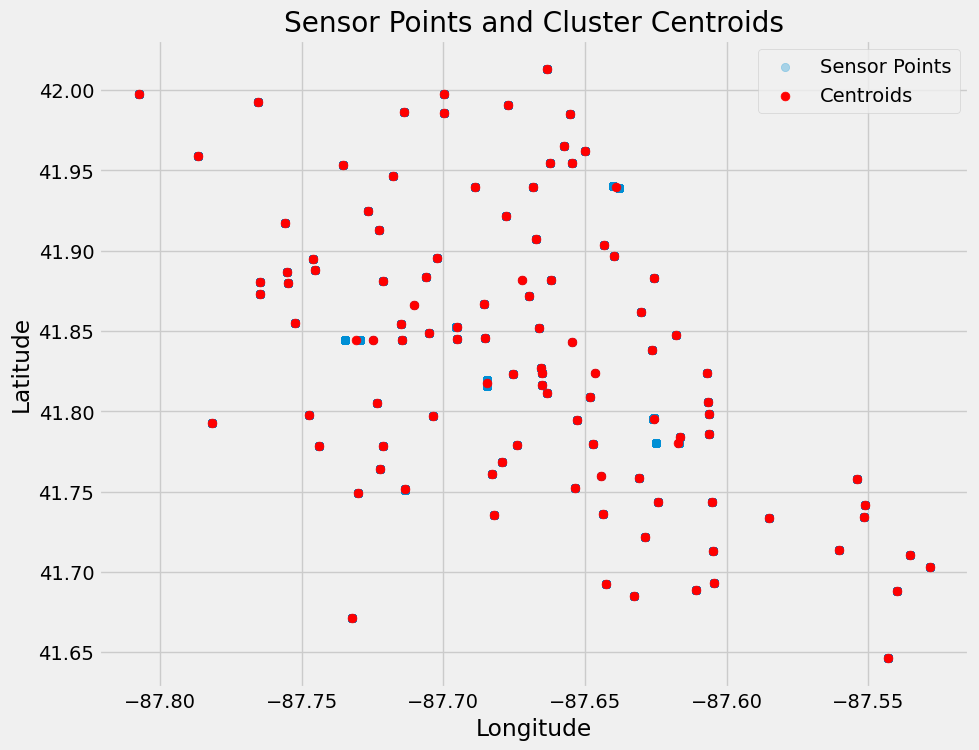

In [ ]:
# 🔵 Graph 2: Cluster Centroids
plt.figure(figsize=(10, 8))
plt.scatter(np.array(clustered_kmeans[0])[:, 1], np.array(clustered_kmeans[0])[:, 0], alpha=0.3, label='Sensor Points')
plt.scatter(clustered_kmeans[1]['Longitude'], clustered_kmeans[1]['Latitude'], c='red', label='Centroids', s=40)
plt.title('Sensor Points and Cluster Centroids')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Step 1: Filter up to 300,000 valid rows

subset = Chicago_df.dropna(subset=['Latitude', 'Longitude', 'CalibratedPM25']).head(500000).copy()

# Step 2: Extract features and scale them

features = subset[['Latitude', 'Longitude', 'CalibratedPM25']].values

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

# Step 3: Apply DBSCAN

db = DBSCAN(eps=0.15, min_samples=3, n_jobs=-1)  # n_jobs=-1 uses all CPU cores

labels = db.fit_predict(scaled_features)

subset['Cluster'] = labels

# Step 4: Remove noise and calculate centroids

clustered = subset[subset['Cluster'] != -1]

centroids = clustered.groupby('Cluster')[['Latitude', 'Longitude']].mean().reset_index()

# Step 5: Plot

# Step 5: Plot with **larger** sensor points

plt.figure(figsize=(14, 12))

plt.scatter(

    clustered['Longitude'],

    clustered['Latitude'],

    c='skyblue',

    s=15,            # ⬅️ Bigger size for sensor points

    alpha=0.7,       # Slight transparency for overlap clarity

    label='Sensor Points'

)

plt.scatter(

    centroids['Longitude'],

    centroids['Latitude'],

    c='red',

    s=50,            # Larger centroids

    marker='o',

    label='Centroids'

)

plt.title("Sensor Points and Cluster Centroids (300,000 Points)", fontsize=16)

plt.xlabel("Longitude")

plt.ylabel("Latitude")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


NameError: name 'Chicago_df' is not defined

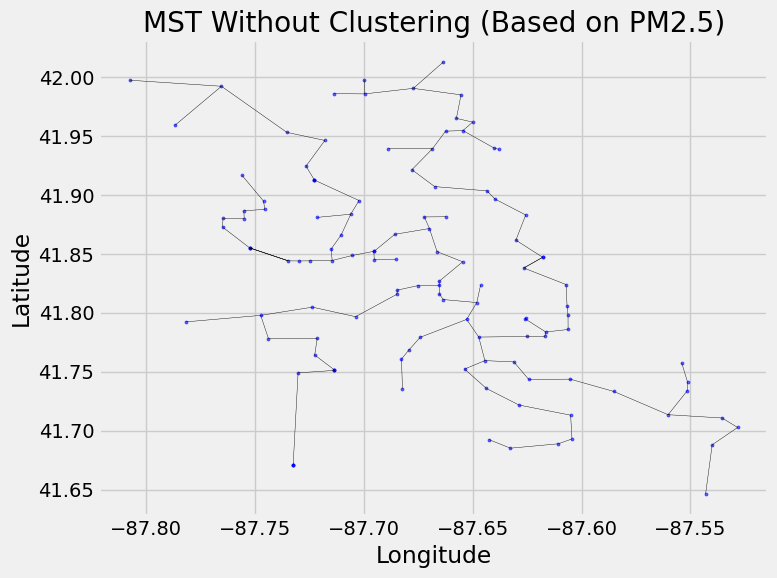

In [ ]:
start_time = time.time()

# Limit to 5000 points to avoid memory issues

dist_matrix = distance_matrix(
    Pollution_By_Sensor[['Latitude', 'Longitude']],
    Pollution_By_Sensor[['Latitude', 'Longitude']]
)
mst = minimum_spanning_tree(dist_matrix).toarray()
elapsed_time = time.time() - start_time

# Step 4: Plot the MST
plt.figure(figsize=(8, 6))
plt.scatter(Pollution_By_Sensor['Longitude'], Pollution_By_Sensor['Latitude'], s=5, color='blue', alpha=0.6)

# Draw MST edges
for i in range(len(mst)):
    for j in range(len(mst)):
        if mst[i][j] > 0:
            plt.plot(
                [Pollution_By_Sensor.loc[i, 'Longitude'], Pollution_By_Sensor.loc[j, 'Longitude']],
                [Pollution_By_Sensor.loc[i, 'Latitude'], Pollution_By_Sensor.loc[j, 'Latitude']],
                'k-', linewidth=0.3
            )

plt.title("MST Without Clustering (Based on PM2.5)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.tight_layout()
plt.savefig("MST_PM25_NoClustering.png")
plt.show()

In [ ]:
mst.sum()

1.9297812091433313

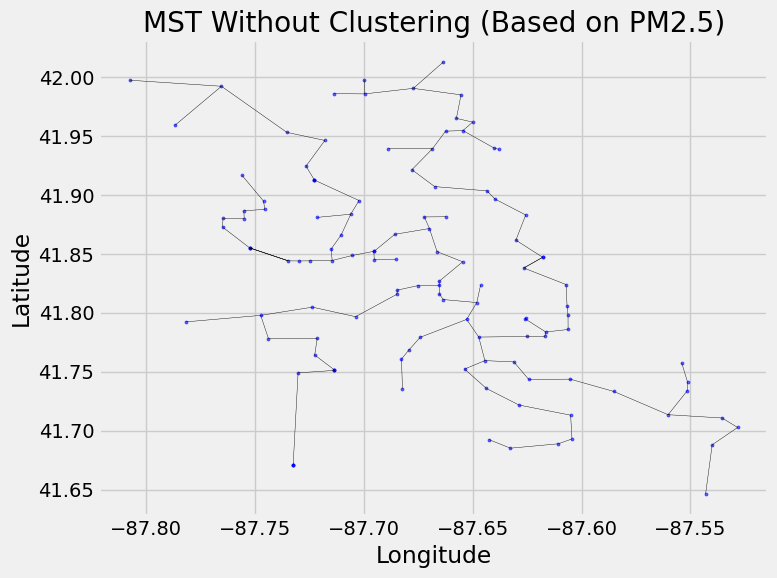

In [ ]:
start_time = time.time()

# Limit to 5000 points to avoid memory issues

dist_matrix = distance_matrix(
    Pollution_By_Geohash[['Latitude', 'Longitude']],
    Pollution_By_Geohash[['Latitude', 'Longitude']]
)
mst = minimum_spanning_tree(dist_matrix).toarray()
elapsed_time = time.time() - start_time

# Step 4: Plot the MST
plt.figure(figsize=(8, 6))
plt.scatter(Pollution_By_Geohash['Longitude'], Pollution_By_Geohash['Latitude'], s=5, color='blue', alpha=0.6)

# Draw MST edges
for i in range(len(mst)):
    for j in range(len(mst)):
        if mst[i][j] > 0:
            plt.plot(
                [Pollution_By_Geohash.loc[i, 'Longitude'], Pollution_By_Geohash.loc[j, 'Longitude']],
                [Pollution_By_Geohash.loc[i, 'Latitude'], Pollution_By_Geohash.loc[j, 'Latitude']],
                'k-', linewidth=0.3
            )

plt.title("MST Without Clustering (Based on PM2.5)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.tight_layout()
plt.savefig("MST_PM25_NoClustering.png")
plt.show()

In [ ]:
mst.sum()

1.9297812091433313

In [ ]:
clustered_dbscan = cluster_data_dbscan(Pollution_By_Sensor)

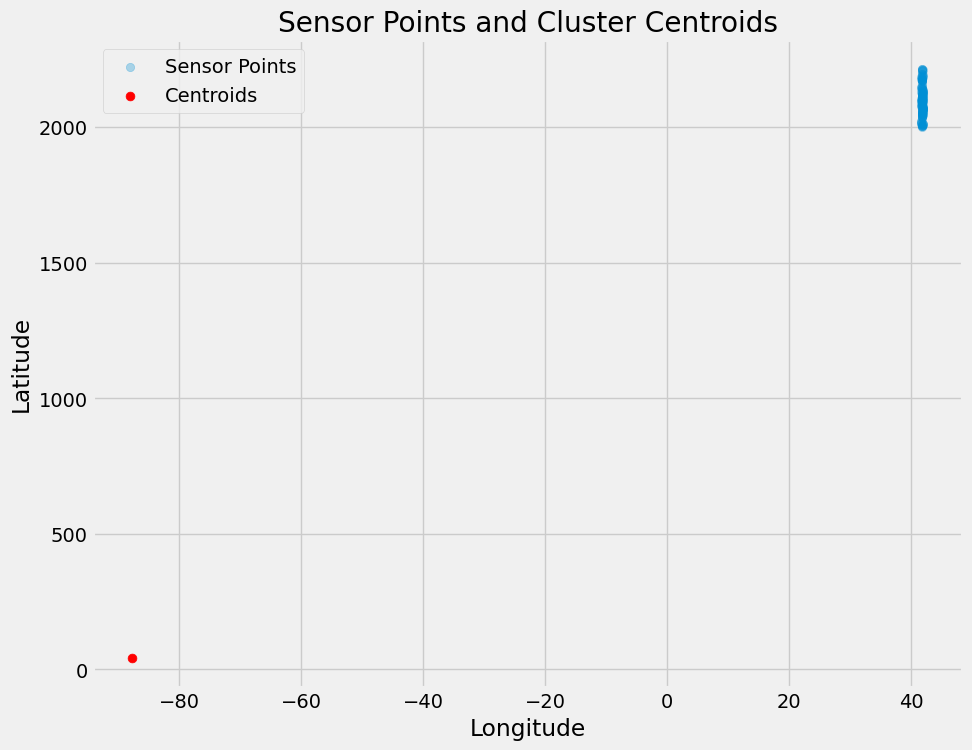

In [ ]:
# 🔵 Graph 2: Cluster Centroids
plt.figure(figsize=(10, 8))
plt.scatter(np.array(clustered_dbscan[0])[:, 1], np.array(clustered_dbscan[0])[:, 0], alpha=0.3, label='Sensor Points')
plt.scatter(clustered_dbscan[1]['Longitude'], clustered_dbscan[1]['Latitude'], c='red', label='Centroids', s=40)
plt.title('Sensor Points and Cluster Centroids')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
clustered_pm = cluster_data_with_pm(Pollution_By_Sensor)

NameError: name 'cluster_data_with_pm' is not defined

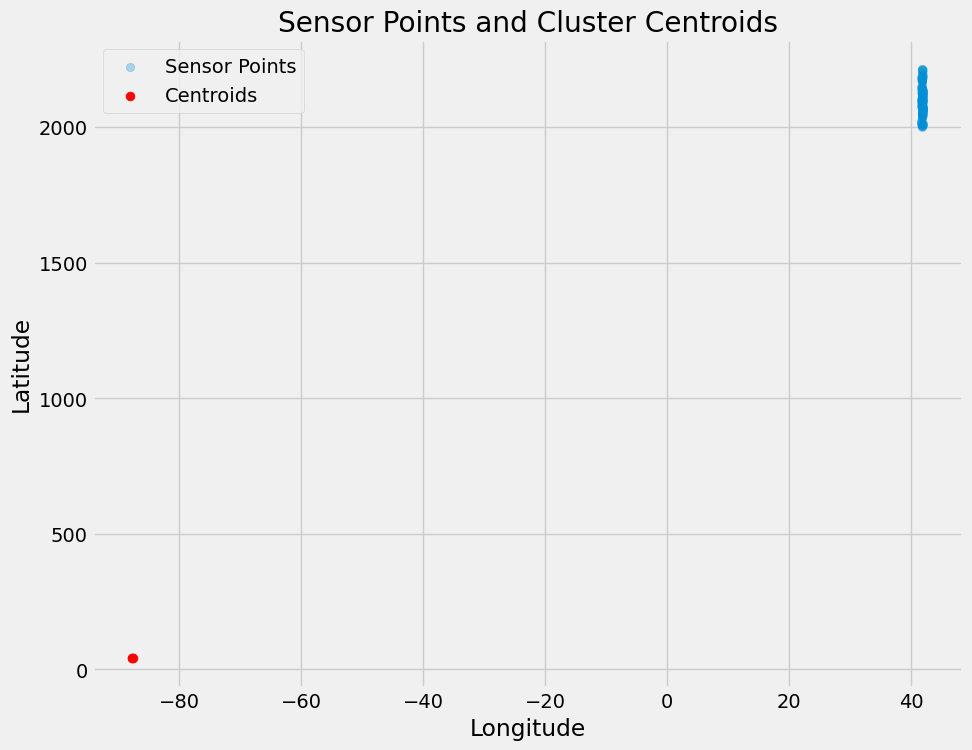

In [ ]:
# 🔵 Graph 2: Cluster Centroids
plt.figure(figsize=(10, 8))
plt.scatter(np.array(clustered_pm[0])[:, 1], np.array(clustered_pm[0])[:, 0], alpha=0.3, label='Sensor Points')
plt.scatter(clustered_pm[1]['Longitude'], clustered_pm[1]['Latitude'], c='red', label='Centroids', s=40)
plt.title('Sensor Points and Cluster Centroids')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
Table().from_df(Chicago_df).group(["DeviceId", "GeoHash Code", "year", "month"])